# Tutorials_paired_modality

In [1]:

import scanpy as sc
import torch
import os
import pandas as pd
os.chdir("/public/home/off_liukunpeng/project/11_cluster_problem/AgaeSMO")


In [2]:
import sys
sys.path.append("/public/home/off_liukunpeng/project/11_cluster_problem/AgaeSMO")

In [3]:
import community as louvain
import AgaeSMO as AgaeSMO_v1

In [4]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


In [5]:
os.environ['R_HOME'] = '/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/R' 


In [6]:

adata_omics1 = sc.read_h5ad("data/Human_Lymph_Node_A1/adata_RNA.h5ad")
adata_omics2 = sc.read_h5ad("data/Human_Lymph_Node_A1/adata_ADT.h5ad")

adata_omics1.var_names_make_unique()
adata_omics2.var_names_make_unique()

/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [7]:
sc.pp.filter_genes(adata_omics1, min_cells=10)
sc.pp.highly_variable_genes(adata_omics1, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(adata_omics1, target_sum=1e4)
sc.pp.log1p(adata_omics1)
sc.pp.scale(adata_omics1)

In [8]:
adata_omics1_high =  adata_omics1[:, adata_omics1.var['highly_variable']]
adata_omics1.obsm['feat'] = AgaeSMO_v1.pca(adata_omics1_high, n_comps=adata_omics2.n_vars-1)
adata_omics1.obsm['tensor']=adata_omics1[:, adata_omics1.var['highly_variable']].X
# adata_omics1.obsm['tensor']=AgaeSMO_v1.pca(adata_omics1_high, n_comps=100)

adata_omics2 = AgaeSMO_v1.clr_normalize_each_cell(adata_omics2)
sc.pp.scale(adata_omics2)
adata_omics2.obsm['feat'] = AgaeSMO_v1.pca(adata_omics2, n_comps=adata_omics2.n_vars-1)
# adata_omics2.obsm['tensor']=AgaeSMO_v1.pca(adata_omics2, n_comps=adata_omics2.n_vars-1)
adata_omics2.obsm['tensor']=adata_omics2.X


------Calculating spatial graph...
The graph contains 20902 edges, 3484 cells.
5.9994 neighbors per cell on average.


/public/home/off_liukunpeng/project/11_cluster_problem/AgaeSMO/AgaeSMO/utils.py:529: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  plot_df = pd.value_counts(pd.value_counts(adata.uns['adj_spatial_']['Cell1']))
/public/home/off_liukunpeng/project/11_cluster_problem/AgaeSMO/AgaeSMO/utils.py:529: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  plot_df = pd.value_counts(pd.value_counts(adata.uns['adj_spatial_']['Cell1']))


------Calculating spatial graph...
The graph contains 20902 edges, 3484 cells.
5.9994 neighbors per cell on average.


/public/home/off_liukunpeng/project/11_cluster_problem/AgaeSMO/AgaeSMO/utils.py:529: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  plot_df = pd.value_counts(pd.value_counts(adata.uns['adj_spatial_']['Cell1']))
/public/home/off_liukunpeng/project/11_cluster_problem/AgaeSMO/AgaeSMO/utils.py:529: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  plot_df = pd.value_counts(pd.value_counts(adata.uns['adj_spatial_']['Cell1']))


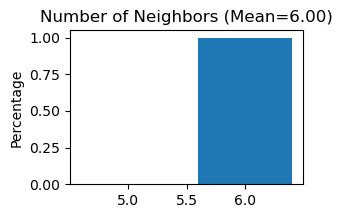

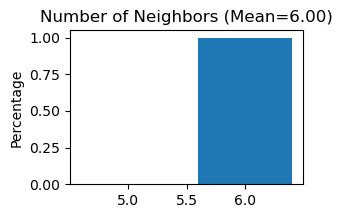

In [9]:
data = AgaeSMO_v1.construct_neighbor_graph(adata_omics1, adata_omics2,6,6,k=6)


In [10]:
model = AgaeSMO_v1.Train_AgaeSMO(data, device=device,learning_rate=0.001,epochs=600,loss_weight=[1,1,1,1])
output = model.train()

torch.Size([3484, 3000]) torch.Size([3484, 31])
dim_input1 3000 dim_input2 31 
 dim_output1 30 dim_output2 30


  0%|          | 0/600 [00:00<?, ?it/s]/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/torch/nn/functional.py:1956: UserWarning: nn.functional.tanh is deprecated. Use torch.tanh instead.
  warnings.warn("nn.functional.tanh is deprecated. Use torch.tanh instead.")
/public/home/off_liukunpeng/project/11_cluster_problem/AgaeSMO/AgaeSMO/layer.py:250: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  self.alpha = F.softmax(torch.squeeze(self.vu) + 1e-6)
  0%|          | 1/600 [00:03<34:10,  3.42s/it]

epoch:0 3.523435115814209


  2%|▏         | 11/600 [00:04<01:31,  6.40it/s]

epoch:10 1.109488844871521


...

epoch:580 0.5169838666915894


 98%|█████████▊| 591/600 [01:01<00:01,  8.62it/s]

epoch:590 0.5164998769760132


100%|██████████| 600/600 [01:02<00:00,  9.54it/s]


Model training finished!



In [11]:
adata = adata_omics1.copy()
adata.obsm['emb_latent_omics1'] = output['emb_latent_omics1'].copy()
adata.obsm['emb_latent_omics2'] = output['emb_latent_omics2'].copy()
adata.obsm['AgaeSMO'] = output['AgaeSMO'].copy()
adata.obsm['alpha'] = output['alpha']

In [21]:
adata=sc.read_h5ad("../AgaeSMO/result/Dataset11_Human_Lymph_Node_A1.h5ad")
adata

AnnData object with n_obs × n_vars = 3484 × 17954
    obs: 'mclust', 'AgaeSMO', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'AgaeSMO_colors', 'adj_spatial', 'adj_spatial_', 'hvg', 'log1p', 'neighbors', 'umap'
    obsm: 'AgaeSMO', 'AgaeSMO_pca', 'X_umap', 'adj_feature', 'alpha', 'emb_latent_omics1', 'emb_latent_omics2', 'feat', 'spatial', 'tensor'
    obsp: 'connectivities', 'distances'

fitting ...
  |======================================================================| 100%
{'ARI': 0.37791564193036475, 'NMI': 0.428201084832614, 'FMS': 0.5287651775711655, 'AMI': 0.4258045792302591, 'HMG': 0.4091611296985109, 'VMS': 0.428201084832614, 'MIS': 0.6902564599166731}


/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to a

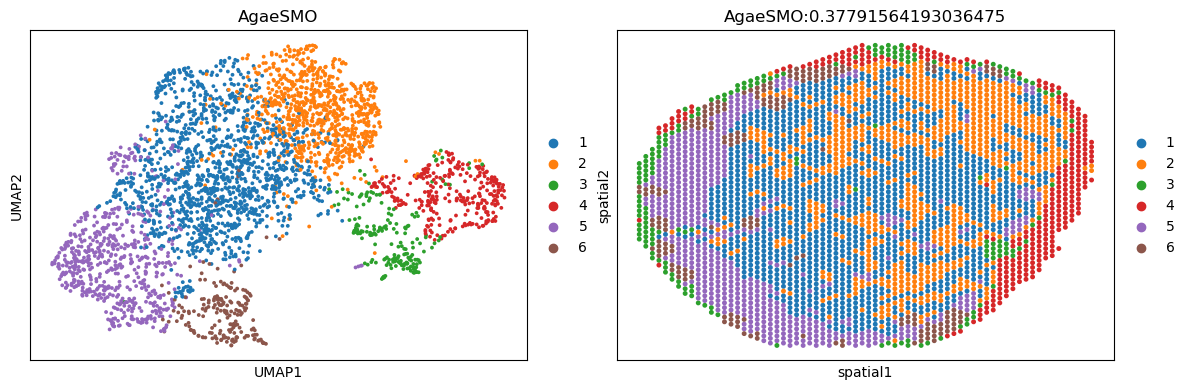

In [22]:

n_cluster=6
tool = 'mclust' # mclust, leiden, and louvain  
AgaeSMO_v1.clustering(adata,refine_=False, key='AgaeSMO', add_key='AgaeSMO', n_clusters=n_cluster, method=tool, use_pca=True)# visualization


annotation=pd.read_csv('data/Human_Lymph_Node_A1/annotation.csv')

adata.obs['Ground Truth']=annotation.loc[:,'manual-anno'].to_list()
indexs=AgaeSMO_v1.supervise_index(adata,"AgaeSMO",'Ground Truth')
print(indexs)

ARI=indexs["ARI"]

import matplotlib.pyplot as plt

fig, ax_list = plt.subplots(1, 2, figsize=(12, 4))
sc.pp.neighbors(adata, use_rep='AgaeSMO', n_neighbors=10)
sc.tl.umap(adata)

sc.pl.umap(adata, color='AgaeSMO', ax=ax_list[0], title='AgaeSMO', s=30, show=False)
sc.pl.embedding(adata, basis='spatial', color='AgaeSMO', ax=ax_list[1], title=f'AgaeSMO:{ARI}', s=50, show=False)

plt.tight_layout(w_pad=0.3)
# plt.show()


